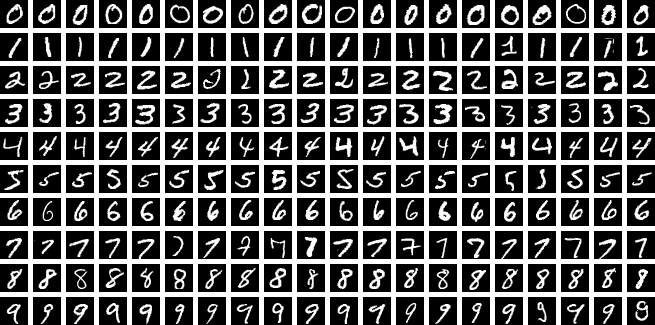

#Imports

In [ ]:
import torch # used for tensor math
import torchvision # used for accessing CV datasets

import torch.nn as nn # used for building neural network layers
import torchvision.transforms as transforms # used for converting and scaling images
from torch.utils.data import DataLoader # used for batching and shuffling training data
import matplotlib.pyplot as plt # used for plotting and visualizing generated images
import torch.nn.functional as F # used for stateless mathematical operations and losses
import torch.optim as optim # used for optimization algorithms

#Preprocesing (transforming and dividing data into batches)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.10MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.3MB/s]


--- INFO ---
Images Shape: torch.Size([32, 1, 28, 28])


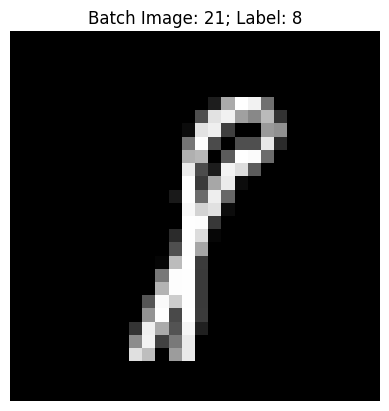

In [ ]:
# a convertor: it converts images to tensors and scales them down to 0-1 (from 0-255)
# we scale them down b/c neural networks do NOT like big numbers
transform = transforms.ToTensor()

# downloads the data (no test set; just a training set which is used to test on too)
train_dataset = torchvision.datasets.MNIST(
    root = './data', # saves to local folder in colab
    train = True, # grabs the training test, not a test set
    transform = transform, # applies convertor
    download = True # downloads 60k images (if set to false, it looks for the dataset in the data folder instead)
)

# PROBLEM: WE CANT FEED A NEURAL NETWORK 60K IMAGES AT ONCE
# THE COLAB MEMORY WOULD CRASH!!!!!
# SOLUTION: only feed in a small set at a time (32, 64, 128, 256, 512), its customisable
batch_size = 32
train_loader = DataLoader(
    dataset = train_dataset,
    batch_size = batch_size,
    shuffle = True # randomizes the order every loop (done to prevent memorizing order)
)

# confirm its working
print("--- INFO ---")
dataiter = iter(train_loader)
images, labels = next(dataiter)
print(f"Images Shape: {images.shape}")
img_index = 20
plt.imshow(images[img_index].squeeze(), cmap='gray')
plt.title(f"Batch Image: {img_index+1}; Label: {labels[img_index].item()}")
plt.axis('off')
plt.show()

# Build VAE (which maps images to Multi-Dimensional Normal Distribution)



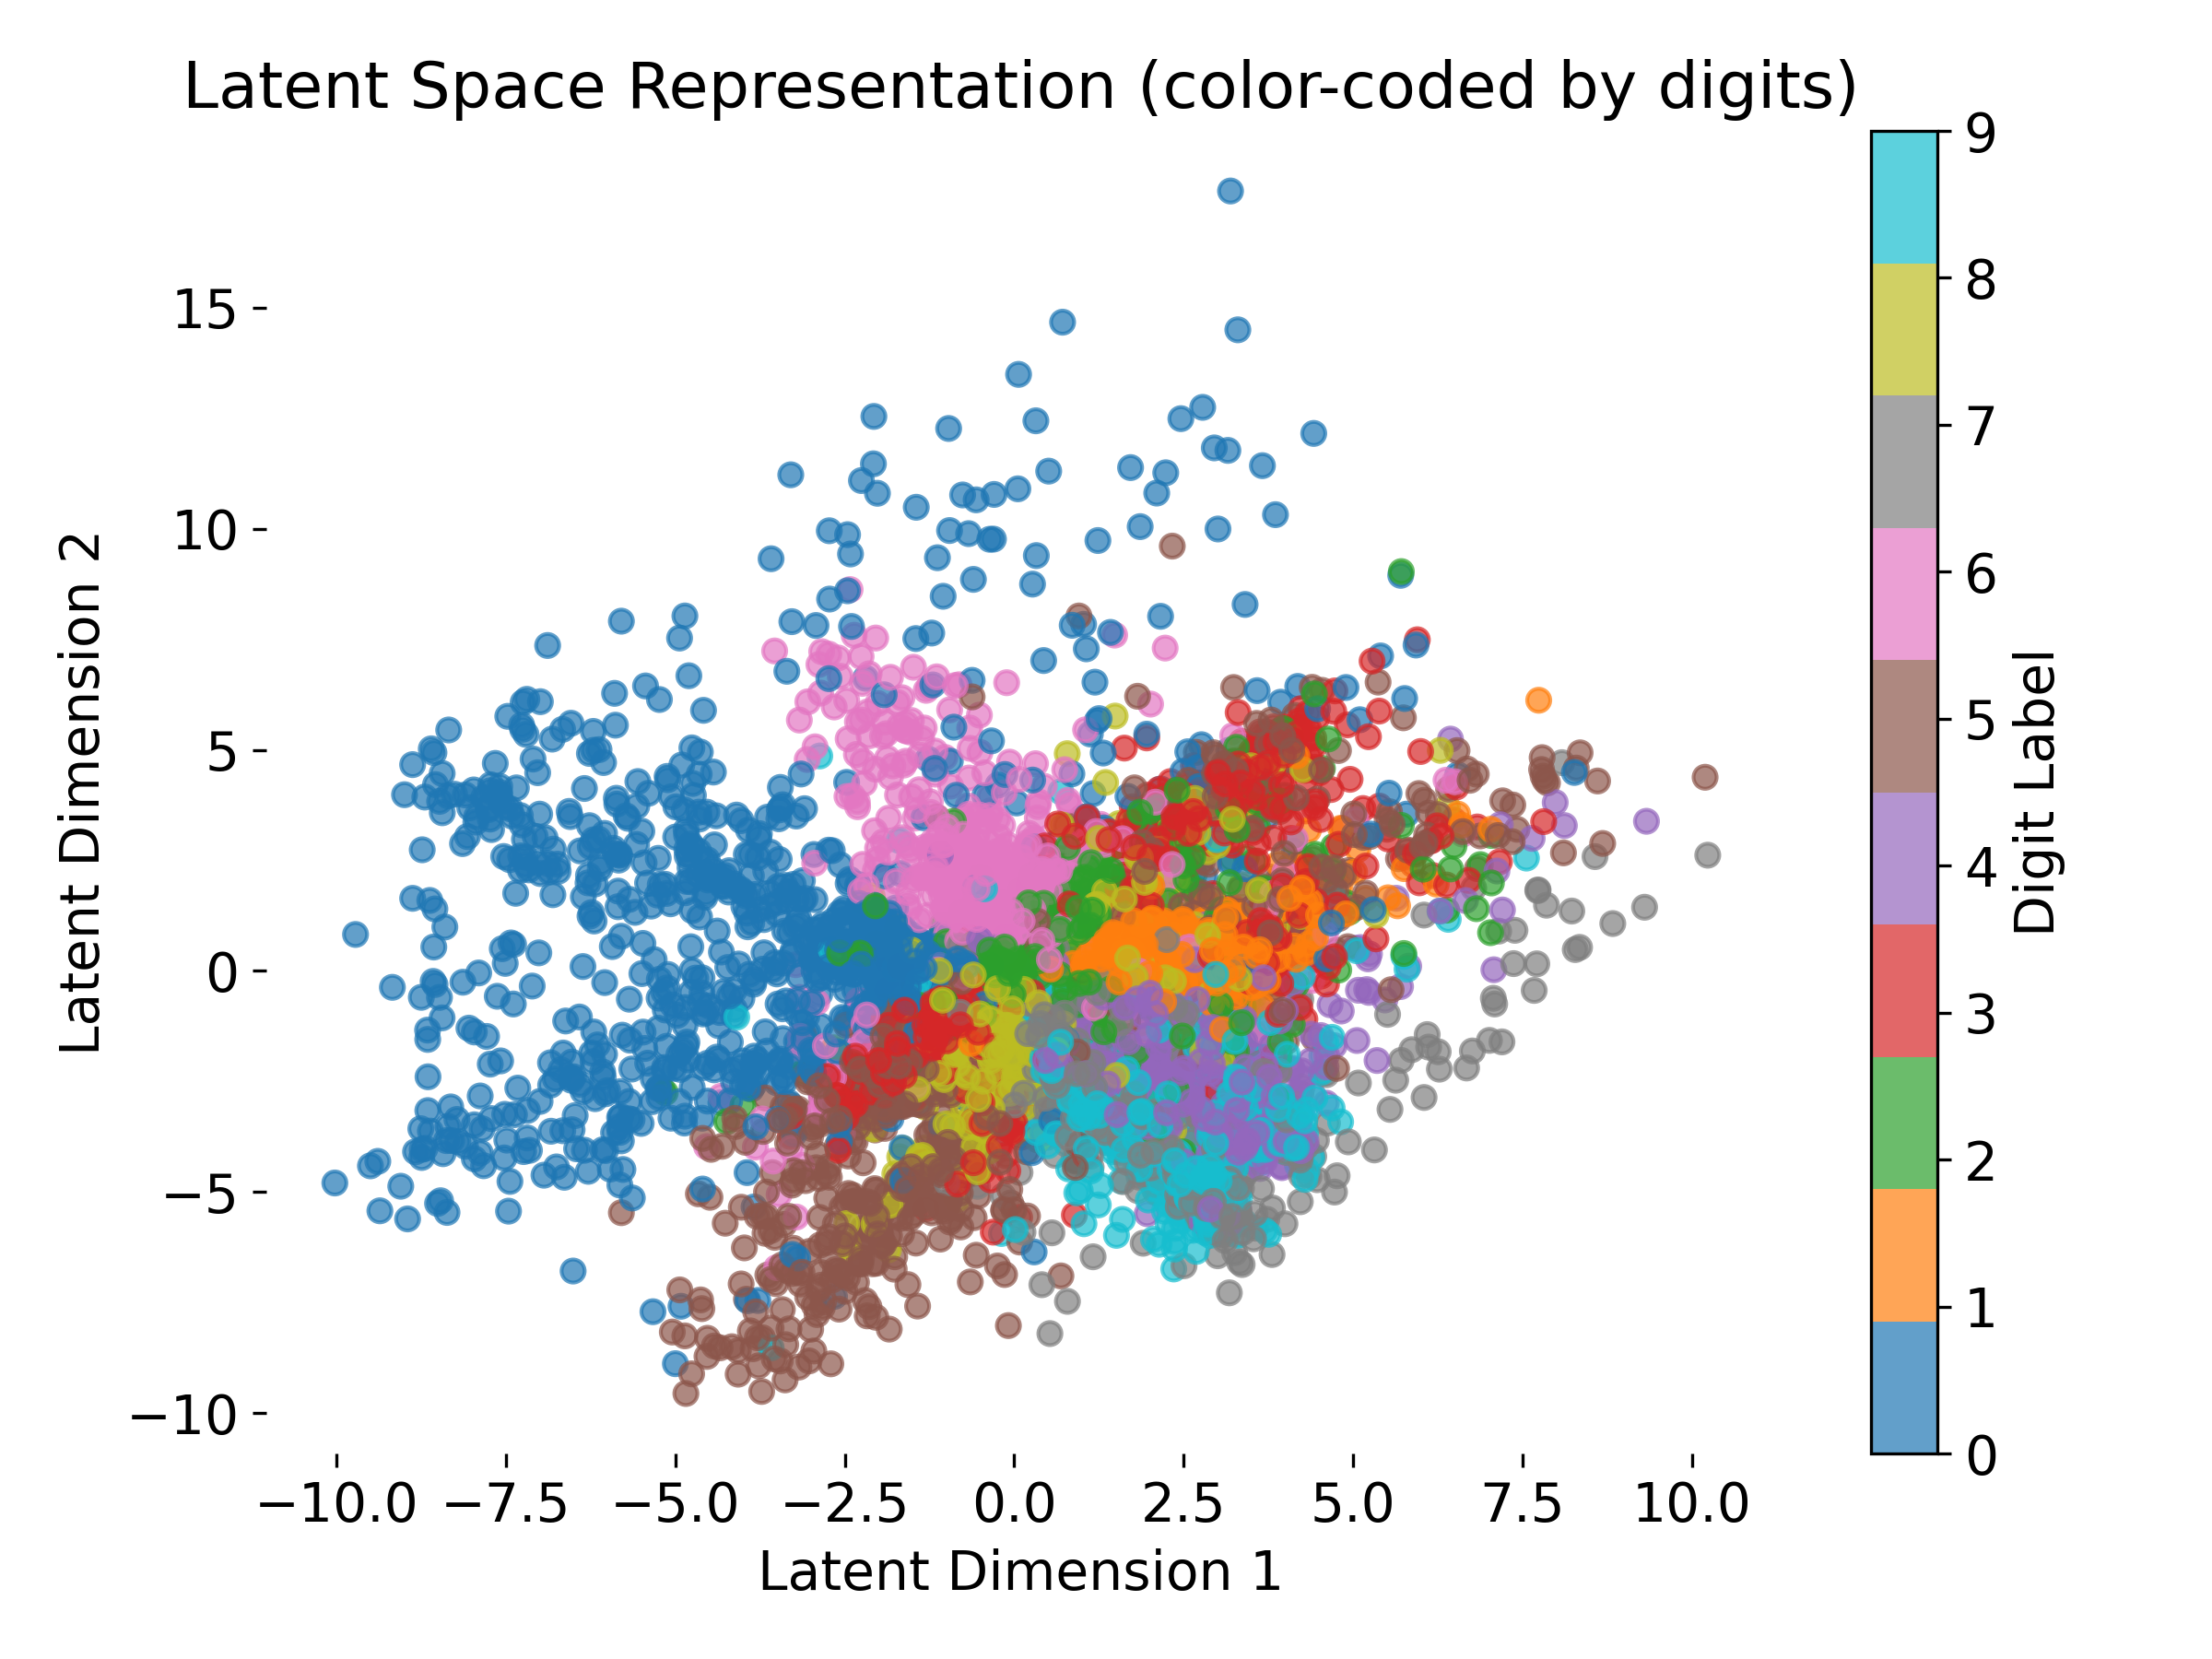

## Components include:
- Encoder
    - Compresses every image into a low-dimensional representation
    - Every single image will have its unique center and variance (center displayed in image)
- Decoder
    - Uncompresses every image into its standard representation (the dims it was originally)

## Functions include:
- encode(self, x)
- reparameterize(self, mu, logvar)
    - We need to randomly sample a point from inside that bubble but backpropgation does NOT like the randomness, so we gotta do a little trick
- decode(self, z)
- forward(self, x)
    - combines the method, feeding the image through the entire network


In [ ]:
class VAE(nn.Module):
    # input dimensions is total pixels! Hidden layer and latent dim are hyperparams
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()

        # --- ENCODER ---
        self.encoder_fc = nn.Linear(input_dim, hidden_dim)

        # a linear layer that takes the hidden features
        # It will learn to output the prob. dist.'s mean
        # at this point its random
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)

        # a separate but identically shaped layer that takes the
        # same hidden features but will learn the log-variance
        # at this point its random
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # --- DECODER ---
        self.decoder_fc1 = nn.Linear(latent_dim, hidden_dim)
        self.decoder_fc2 = nn.Linear(hidden_dim, input_dim)

    # takes an image, passes it through the first layer
    # an applies a ReLU activation to get a hiddent state h
    # 784 -> 400
    def encode(self, x):
        h = F.relu(self.encoder_fc(x))
        return self.fc_mu(h), self.fc_logvar(h) #returns two separate stuff

    # we do the trick here
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar) # changes logvar into std
        eps = torch.randn_like(std) # generates noise similar to std
        # the math: z = mu + epsilon*std (this is point)
        return mu + eps * std

    # sigmoid activation function forces every number (of the 784) be between 0.0 and 1.0.
    # it guarantees that BCE can handle the network's output
    def decode(self, z):
        h = F.relu(self.decoder_fc1(z))
        return torch.sigmoid(self.decoder_fc2(h))


    def forward(self, x):
        # flattens our images
        x_flat = x.view(x.size(0), -1)
        # images are passed into the encoder, which calculates and returns specific centers, and log-variances for images
        mu, logvar = self.encode(x_flat)
        # does the magic
        z = self.reparameterize(mu, logvar)
        # reconstructs the image
        x_reconstructed = self.decode(z)

        return x_reconstructed, mu, logvar

# Instantiate the model and move it to the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE().to(device)

print(f"Model successfully built and moved to: {device}")

Model successfully built and moved to: cuda


# Cost Function (which the model uses to train)


## Components include:
- Binary Cross-Entropy loss function (measures how far off the model's prediction was; it takes confidence into account)
- Kullback–Leibler Divergence loss function (measures how far a probability distribution is from another)

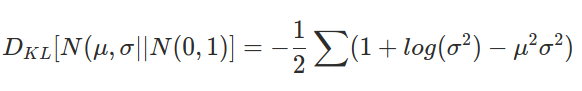

In [ ]:
# Calculates the VAE loss function: Reconstruction Loss + KL Divergence.
# reconstrcuted_x is the generated image
# x is the real image
# mu is the 20-dim vector from fc_mu
# logvar is the 20-dim vector from fc_logvar

# BCE AND KLD EQs. ARE MATHEMATHICALLY PROVEN
# LAWS OF PROBABILITY; NOT TO BE TUNED !!
def vae_loss_function(reconstructed_x, x, mu, logvar):
    # reconstruction loss (how good is the drawing?)
    # we use .view(-1, 784) b/c you need to view the image as flat
    # it punishes highly confident wrong guesses on pixel values
    # it actively punishes gray guesses since out pixels shouldnt really be gray
    BCE = F.binary_cross_entropy(reconstructed_x, x.view(-1, 784), reduction='sum')

    # kl divergence (how well-organized is the map?)
    # goal: every image's dist. should look like a stand. norm. dist. N(0,1)
    # mu.pow(2): squares the mean to make it have a huge penalty if not at 0
    # logvar: log of the variance
    # logvar.exp(): the variance
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # total loss
    # BCE forces them to not clump up (since reconstruction loss would skyrocket)
    # KLD forces them to to all map to a stand. norm. dist., so they have similar-sized regions
    return BCE + KLD

#Normal Gradient Descent

In [ ]:
epochs = 10
learning_rate = 1e-3

print("Starting Training Loop...")

model.train()

for epoch in range(epochs):
    train_loss = 0

    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)

        # manually zero out gradients
        if model.parameters():
            for param in model.parameters():
                if param.grad is not None:
                    param.grad.zero_()

        reconstructed_batch, mu, logvar = model(data)
        loss = vae_loss_function(reconstructed_batch, data, mu, logvar)
        loss.backward()

        # manually update weights using vanilla gradient descent: w = w - lr * grad
        with torch.no_grad():
            for param in model.parameters():
                if param.grad is not None:
                    param.data -= learning_rate * param.grad

        train_loss += loss.item()

    avg_loss = train_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}] \t Average Loss: {avg_loss:.4f}")

print("--- Done!!! ---")

Starting Training Loop...


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


#Adam Optimizer(No Eve 😞)

In [ ]:
# --- DO WHAT U WANT HERE ---
epochs = 10
learning_rate = 1e-3

# Initialize the Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print("Starting Training Loop...")

# Enable anomaly detection for more informative tracebacks
# This can help pinpoint the exact operation causing CUDA errors.
torch.autograd.set_detect_anomaly(True)

# important if theres certain layers like Dropout/BatchNorm if you decide to add it
model.train()

for epoch in range(epochs):
    train_loss = 0

    # iterate through the batches from our DataLoader
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        reconstructed_batch, mu, logvar = model(data)

        # calculate the VAE loss
        loss = vae_loss_function(reconstructed_batch, data, mu, logvar)

        # Check for NaN/Inf in loss to catch numerical instabilities early
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"Epoch {epoch+1}, Batch {batch_idx}: Detected NaN or Inf in loss. Skipping batch.")
            continue # Skip this batch if loss is problematic

        # backward pass/propagation
        loss.backward()

        # (for tracking)
        train_loss += loss.item()

        # update the weights
        optimizer.step()

    avg_loss = train_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}] \t Average Loss: {avg_loss:.4f}")

print("--- Done!!! ---")

Starting Training Loop...


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


#Synthetic Digits

Generating synthetic digits from random noise...


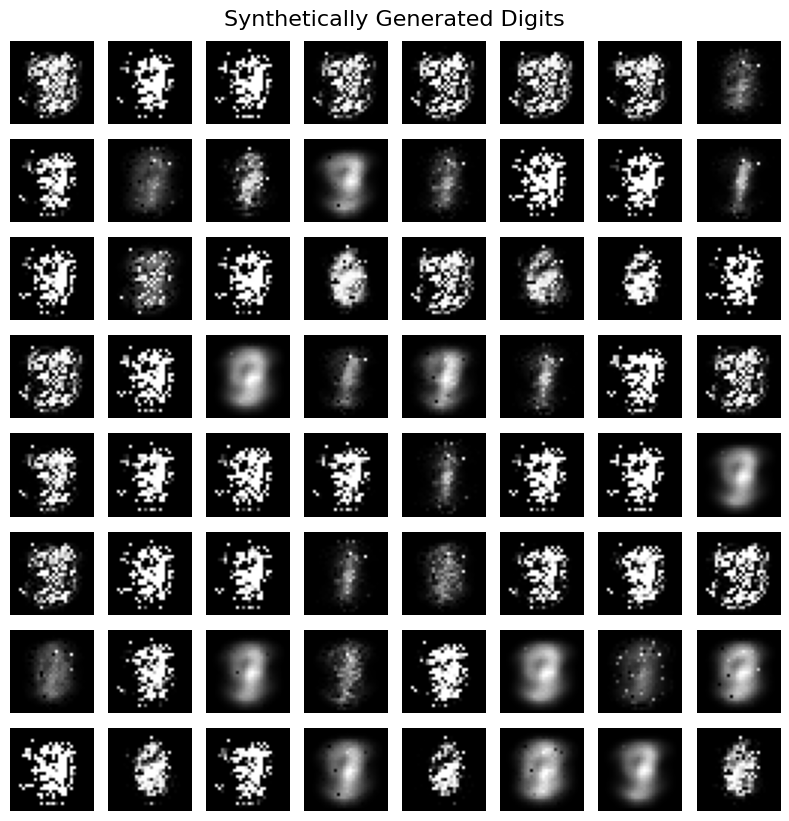

In [ ]:
print("Generating synthetic digits from random noise...")

# set the model to evaluation mode (turns off gradients and specific training layers)
model.eval()

# how many images we want to generate
num_images = 64
latent_dim = 20 # Must match the latent_dim defined in your VAE class

# sample pure random noise from a standard normal distribution
random_latent_vectors = torch.randn(num_images, latent_dim).to(device)


with torch.no_grad():
    generated_images = model.decode(random_latent_vectors)

generated_images = generated_images.view(num_images, 1, 28, 28).cpu()

# Plot the results in an 8x8 grid
fig, axes = plt.subplots(8, 8, figsize=(8, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated_images[i].squeeze(), cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.suptitle("Synthetically Generated Digits", fontsize=16, y=1.02)
plt.show()